In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## NACC Data

In [ ]:
data_sample = pd.read_csv("/content/drive/MyDrive/investigator_ftldlbd_nacc67.csv", nrows=5)

In [ ]:
data_sample.shape

(5, 1936)

In [ ]:
data_dict = pd.read_csv('/content/drive/MyDrive/uds3-rdd.csv', encoding='ISO-8859-1')

In [ ]:
data_dict.head()

,VariableName,Form,VariableType,ShortDescriptor,DataType,AllowableCodes
0,NACCID,header,NACC derived variable,Subject ID number,Numeric longitudinal,Prefix NACC followed by 0 - 10 numbers
1,NACCADC,header,NACC derived variable,ADC at which subject was seen,Numeric cross-sectional,100 -9999
2,PACKET,header,Original UDS question,Packet code,Numeric longitudinal,I = Initial Visit Packet\n F = Follow-up Visi...
3,FORMVER,header,Original UDS question,Form version number,Numeric longitudinal,1 - 3.2
4,VISITMO,header,Original UDS question,Form date - month,Numeric longitudinal,1 - 12


In [ ]:
columns_to_be_read = list(set.intersection(set(data_sample.columns), set(data_dict['VariableName'].to_list())))

In [ ]:
data2 = pd.read_csv("/content/drive/MyDrive/investigator_ftldlbd_nacc67.csv", usecols=columns_to_be_read)

In [ ]:
data2.shape

(195196, 760)

In [ ]:
null_list = []
for i in data2.columns:
    if data2[i].isna().sum()/data2.shape[0]>0.3:
        null_list.append(i)

In [ ]:
data_filtered = data2.drop(columns = null_list)

In [ ]:
data_filtered.shape

(195196, 685)

In [ ]:
data_filtered['VISIT_DATE'] = pd.to_datetime(data_filtered[['VISITYR', 'VISITMO', 'VISITDAY']].rename(
    columns={'VISITYR': 'year', 'VISITMO': 'month', 'VISITDAY': 'day'}))

data_filtered.drop(columns = ['VISITYR', 'VISITMO', 'VISITDAY'], inplace = True)

In [ ]:
data_dict1 = data_dict[data_dict['VariableName'].isin(list(set.intersection(set(data_filtered.columns), set(data_dict['VariableName'].to_list()))))]

In [ ]:
form_dict_temp = {}
for form in data_dict1['Form'].unique():
    form_dict_temp[form] = {
        row['VariableName']: {
            'AllowableCodes': row['AllowableCodes'],
            'ShortDescriptor': row['ShortDescriptor'],
            'DataType': row['DataType']
        }
        for _, row in data_dict1[data_dict1['Form'] == form].iterrows()
    }
    if form != 'header':
        form_dict_temp[form].update({
            'NACCID': {'AllowableCodes': None, 'ShortDescriptor': None, 'DataType':None},
            'VISIT_DATE': {'AllowableCodes': None, 'ShortDescriptor': None, 'DataType':None}
        })

In [ ]:
form_dict_temp.keys()

dict_keys(['header', 'milestones', 'other', 't1', 'a1', 'a2', 'a3', 'a4', 'a5', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'c1c2', 'c1c2c2t', 'c1', 'c2c2t', 'c2', 'c2t', 'd1', 'd2'])

In [ ]:
data_filtered1 = data_filtered.drop(columns=[i for i in form_dict_temp['a2'] if i not in ['NACCID', 'VISIT_DATE']])
# data_filtered1 = data_filtered1.drop(columns=[i for i in form_dict_temp['a3'] if i not in ['NACCID', 'VISIT_DATE']])
data_filtered1 = data_filtered1.drop(columns=[i for i in form_dict_temp['milestones'] if i not in ['NACCID', 'VISIT_DATE']])
data_filtered1 = data_filtered1.drop(columns=[i for i in form_dict_temp['header'] if i not in ['NACCID', 'VISIT_DATE']])
data_filtered1 = data_filtered1.drop(columns=[i for i in form_dict_temp['other'] if i not in ['NACCID', 'VISIT_DATE']])
data_filtered1 = data_filtered1.drop(columns=[i for i in form_dict_temp['t1'] if i not in ['NACCID', 'VISIT_DATE']])

In [ ]:
a1_filter = [i for i in form_dict_temp['a1'] if i not in ['INDEPEND', 'NACCAGE', 'NACCAGEB', 'SEX', 'EDUC', 'NACCLIVS', 'NACCID', 'VISIT_DATE']]

In [ ]:
data_filtered1 = data_filtered1.drop(columns=a1_filter)

In [ ]:
data_filtered1.shape

(195196, 618)

In [ ]:
ad_data = data_filtered1.copy()

In [ ]:
# Drop specified keys
keys_to_remove = ['header', 'milestones', 'other', 't1', 'a2']
filtered_dict = {key: value for key, value in form_dict_temp.items() if key not in keys_to_remove}

In [ ]:
filtered_dict.keys()

dict_keys(['a1', 'a3', 'a4', 'a5', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'c1c2', 'c1c2c2t', 'c1', 'c2c2t', 'c2', 'c2t', 'd1', 'd2'])

In [ ]:
filtered_dict['a1'] = {key: value for key, value in form_dict_temp['a1'].items() if key not in a1_filter}

In [ ]:
# List of keywords to check for null-like values
null_keywords = ["unknown", "not available", "not assessed", "not administered", "not applicable", 'did not answer', 'did not complete medications form']

for form in filtered_dict.keys():
    for col in list(filtered_dict[form].keys())[:-2]:
        # Extract AllowableCodes
        allowable_codes = filtered_dict[form][col]['AllowableCodes'].split('\n')

        # Initialize the null values list
        null_values = []

        for code in allowable_codes:
            # Check if any null-like keyword is in the description (case-insensitive)
            if any(keyword in code.lower() for keyword in null_keywords):
                # Extract the number (before the '=' sign)
                number = float(code.split('=')[0].strip().replace(' ', ''))
                null_values.append(number)

        # Add the null_values key to the column's dictionary
        filtered_dict[form][col]['null_values'] = null_values

## Data exploration

In [ ]:
# function to plot histograms
def plot_histogram(data, column_name):
    plt.hist(data[column_name], bins=10, edgecolor='black')
    plt.title(f'Histogram of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
def analyse_data(data, k):
    for i in data.columns[k:]:
        if data[i].nunique()>12:
            plot_histogram(data, i)
        else:
            print(data[i].value_counts())

In [ ]:
def analyse_data2(data, form_dict, form, k):
    for column in data.columns[k:]:
        null_values = form_dict[form][column]['null_values']

        # Filter out null-like values from the column
        filtered_data = data[~data[column].isin(null_values)]

        if filtered_data[column].nunique() > 12:
            plot_histogram(filtered_data, column)

In [ ]:
def cross_sectional_features(form_dict, form):
    cross_sectional_features = ['NACCID']
    longitudinal_features = ['NACCID', 'VISIT_DATE']
    for i in list(form_dict[form].keys())[:-2]:
        if 'cross-sectional' in form_dict[form][i]['DataType']:
            cross_sectional_features.append(i)
        else:
            longitudinal_features.append(i)
    return cross_sectional_features, longitudinal_features

In [ ]:
def data_split(form_dict, form, data):
    l1, l2 = cross_sectional_features(form_dict, form)
    if l1:
      data_filtered1 = data[l1].drop_duplicates()
    data_filtered2 = data[l2]
    return data_filtered1, data_filtered2

In [ ]:
def bucket_feature(data, feature, bins, labels=None, right=True):
    if labels and len(labels) != len(bins) - 1:
        raise ValueError("Number of labels must be one less than the number of bin edges.")
    bucketed_feature = pd.cut(data[feature], bins=bins, labels=labels, right=right, include_lowest=True)
    return bucketed_feature

In [ ]:
def null_percentage(form_dict, data, form, threshold=0.3):
    drop_list = []
    for i in list(form_dict[form].keys())[:-2]:  # Exclude the last two keys
        if form_dict[form][i]['null_values']:  # Check if 'null_values' exists
            # Get the null values for the column
            null_values = form_dict[form][i]['null_values']

            # Calculate the percentage of null-like values
            null_count = data[data[i].isin(null_values)].shape[0]
            null_percentage = null_count / data.shape[0]

            form_dict[form][i]['null_percentage'] = null_percentage

            # Check if the percentage exceeds the threshold
            if null_percentage > threshold:
                form_dict[form][i]['drop_column'] = "Yes"
                drop_list.append(i)
            else:
                form_dict[form][i]['drop_column'] = "No"
    return drop_list

In [ ]:
finaldict = filtered_dict.copy()

### a1: Demographics

In [ ]:
a1_drop_columns = null_percentage(filtered_dict, ad_data, 'a1', threshold=0.3)
a1_drop_columns

[]

In [ ]:
a1_data1, a1_data2 = data_split(filtered_dict, 'a1', ad_data)

SEX
2    30105
1    22432
Name: count, dtype: int64


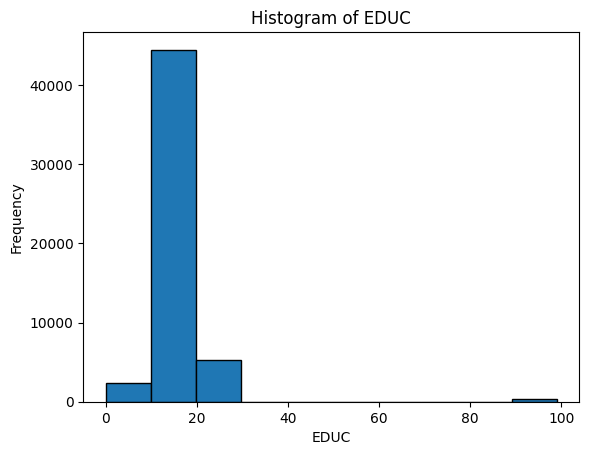

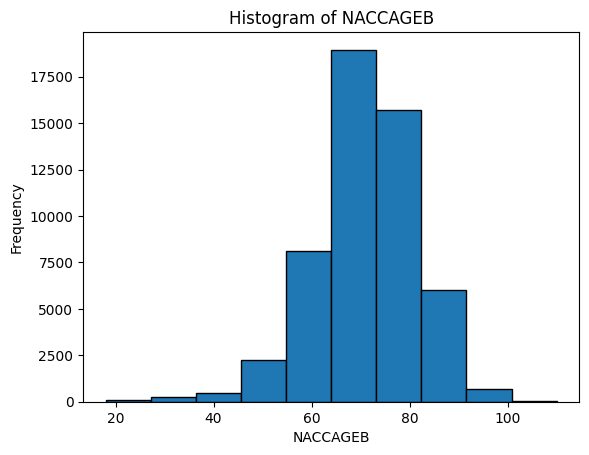

In [ ]:
analyse_data(a1_data1, 1)

In [ ]:
age_bins = [0, 75, 85, 120]
age_labels = ['<75', '75-85', '85+']
a1_data1['age_bucket'] = bucket_feature(a1_data1, 'NACCAGEB', age_bins, age_labels)

experience_bins = [0, 10, 15, 36]
experience_labels = ['not educated', 'Educated', 'Highly Educated']
a1_data1['education_bucket'] = bucket_feature(a1_data1, 'EDUC', experience_bins, experience_labels)

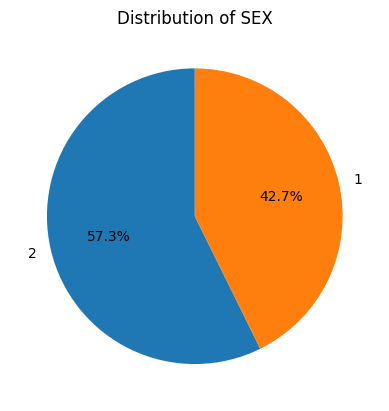

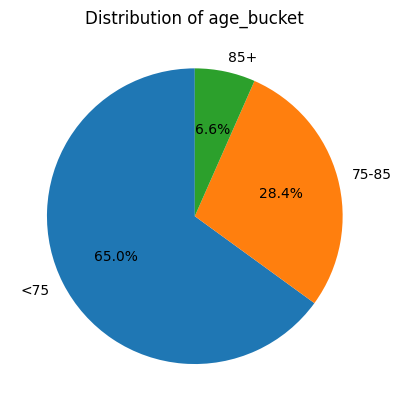

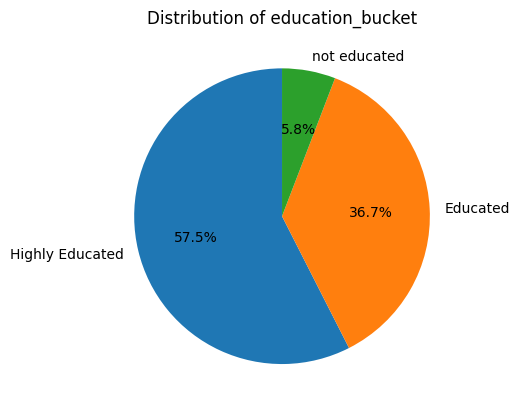

In [ ]:
for i in ['SEX', 'age_bucket', 'education_bucket']:
    plt.pie(
        a1_data1[i].value_counts().to_list(),  # Counts for each category
        labels=a1_data1[i].value_counts().index,  # Categories as labels
        autopct='%1.1f%%',  # Percentage formatting
        startangle=90  # Rotate the pie chart
    )
    plt.title(f'Distribution of {i}')  # Add a title for context
    plt.show()  # Display the pie chart

NACCLIVS
2    114901
1     49827
3     15487
4     10916
5      3741
9       324
Name: count, dtype: int64
INDEPEND
1    134206
2     31748
3     17889
4     10756
9       597
Name: count, dtype: int64


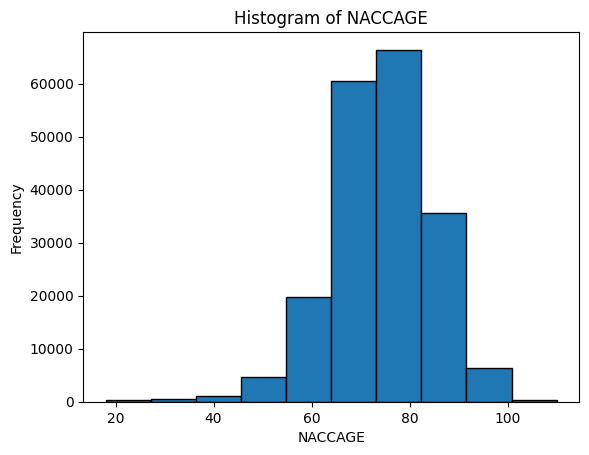

In [ ]:
analyse_data(a1_data2, 2)

In [ ]:
filtered_dict['a1']

{'SEX': {'AllowableCodes': ' 1 = Male\n2 = Female',
  'ShortDescriptor': "Subject's sex",
  'DataType': 'Numeric cross-sectional',
  'null_values': []},
 'EDUC': {'AllowableCodes': ' 0  - 36\n99 = Unknown',
  'ShortDescriptor': 'Years of education',
  'DataType': 'Numeric cross-sectional',
  'null_values': [99.0],
  'null_percentage': 0.004989856349515359,
  'drop_column': 'No'},
 'NACCLIVS': {'AllowableCodes': ' 1 = Lives alone\n2 = Lives with spouse or partner \n3 = Lives with relative or friend \n4 = Lives with group \n5 = Other \n9 = Unknown',
  'ShortDescriptor': 'Living situation',
  'DataType': 'Numeric longitudinal',
  'null_values': [9.0],
  'null_percentage': 0.0016598700793049037,
  'drop_column': 'No'},
 'INDEPEND': {'AllowableCodes': ' 1 = Able to live independently \n2 = Requires some assistance with complex activities \n3 = Requires some assistance with basic activities \n4 = Completely dependent \n9 = Unknown',
  'ShortDescriptor': 'Level of independence',
  'DataType':

## a3: Subject family history

In [ ]:
a3_drop_columns = null_percentage(filtered_dict, ad_data, 'a3', threshold=0.3)
a3_drop_columns

['NACCFADM',
 'NACCAM',
 'NACCAMS',
 'NACCFFTD',
 'NACCFM',
 'NACCFMS',
 'NACCOM',
 'NACCOMS']

In [ ]:
a3_data1, a3_data2 = data_split(filtered_dict, 'a3', ad_data)
print(a3_data1.shape)
print(a3_data2.shape)

(52537, 12)
(195196, 2)


In [ ]:
a3_data1.drop(columns = [i for i in a3_data1.columns if i in a3_drop_columns], inplace=True)
a3_data1.shape

(52537, 4)

In [ ]:
analyse_data(a3_data1, 1)

NACCFAM
 1    26969
 0    18996
 9     5951
-4      621
Name: count, dtype: int64
NACCMOM
 0    33335
 1    17096
 9     1485
-4      621
Name: count, dtype: int64
NACCDAD
 0    41181
 1     8501
 9     2234
-4      621
Name: count, dtype: int64


In [ ]:
ad_data.drop(columns = a3_drop_columns, inplace=True)

In [ ]:
for key in a3_drop_columns:
    finaldict['a3'].pop(key, None)

### a4: Subject medications

In [ ]:
a4_drop_columns = null_percentage(filtered_dict, ad_data, 'a4', threshold=0.3)
a4_drop_columns

[]

In [ ]:
for i in list(filtered_dict['a4'].keys())[:-2]:
    print(i)
    print(filtered_dict['a4'][i]['null_percentage'])

ANYMEDS
0.014032049837086825
NACCAMD
0.014032049837086825
NACCAHTN
0.014032049837086825
NACCHTNC
0.014032049837086825
NACCACEI
0.014032049837086825
NACCAAAS
0.014032049837086825
NACCBETA
0.014032049837086825
NACCCCBS
0.014032049837086825
NACCDIUR
0.014032049837086825
NACCVASD
0.014032049837086825
NACCANGI
0.014032049837086825
NACCLIPL
0.014032049837086825
NACCNSD
0.014032049837086825
NACCAC
0.014032049837086825
NACCADEP
0.014032049837086825
NACCAPSY
0.014032049837086825
NACCAANX
0.014032049837086825
NACCADMD
0.014032049837086825
NACCPDMD
0.014032049837086825
NACCEMD
0.014032049837086825
NACCEPMD
0.014032049837086825
NACCDBMD
0.014032049837086825


In [ ]:
a4_data1, a4_data2 = data_split(filtered_dict, 'a4', ad_data)
print(a4_data1.shape)
print(a4_data2.shape)

(52537, 1)
(195196, 24)


ANYMEDS
 1    184813
 0      7644
-4      2739
Name: count, dtype: int64


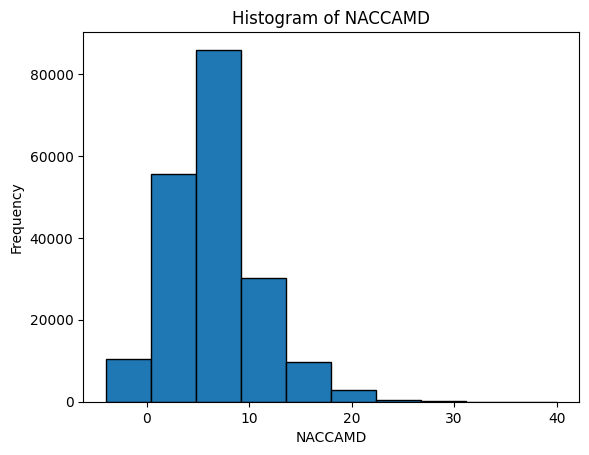

NACCAHTN
 1    106347
 0     86110
-4      2739
Name: count, dtype: int64
NACCHTNC
 0    184309
 1      8148
-4      2739
Name: count, dtype: int64
NACCACEI
 0    160450
 1     32007
-4      2739
Name: count, dtype: int64
NACCAAAS
 0    175223
 1     17234
-4      2739
Name: count, dtype: int64
NACCBETA
 0    152785
 1     39672
-4      2739
Name: count, dtype: int64
NACCCCBS
 0    161167
 1     31290
-4      2739
Name: count, dtype: int64
NACCDIUR
 0    162923
 1     29534
-4      2739
Name: count, dtype: int64
NACCVASD
 0    188674
 1      3783
-4      2739
Name: count, dtype: int64
NACCANGI
 0    168708
 1     23749
-4      2739
Name: count, dtype: int64
NACCLIPL
 0    105568
 1     86889
-4      2739
Name: count, dtype: int64
NACCNSD
 0    112507
 1     79950
-4      2739
Name: count, dtype: int64
NACCAC
 0    115057
 1     77400
-4      2739
Name: count, dtype: int64
NACCADEP
 0    135173
 1     57284
-4      2739
Name: count, dtype: int64
NACCAPSY
 0    184084
 1      8373
-4    

In [ ]:
analyse_data(a4_data2, 2)

### a5: Subject health history

In [ ]:
a5_drop_columns = null_percentage(filtered_dict, ad_data, 'a5', threshold=0.4)
a5_drop_columns

['QUITSMOK',
 'ALCOCCAS',
 'ALCFREQ',
 'HATTMULT',
 'HATTYEAR',
 'CVPACDEF',
 'CVPACE',
 'CVANGINA',
 'CVHVALVE',
 'STROKMUL',
 'NACCSTYR',
 'TIAMULT',
 'NACCTIYR',
 'PDYR',
 'PDOTHRYR',
 'TBI',
 'TBIBRIEF',
 'TRAUMBRF',
 'TBIEXTEN',
 'TRAUMEXT',
 'TBIWOLOS',
 'TRAUMCHR',
 'TBIYEAR',
 'NCOTHR',
 'DIABTYPE',
 'ARTHRIT',
 'ARTHTYPE',
 'ARTHUPEX',
 'ARTHLOEX',
 'ARTHSPIN',
 'ARTHUNK',
 'APNEA',
 'RBD',
 'INSOMN',
 'OTHSLEEP',
 'PTSD',
 'BIPOLAR',
 'SCHIZ',
 'ANXIETY',
 'OCD',
 'NPSYDEV']

In [ ]:
for i in list(filtered_dict['a5'].keys())[:-2]:
    if filtered_dict['a5'][i]['null_percentage'] < 0.4:
        print(i)

TOBAC30
TOBAC100
SMOKYRS
PACKSPER
CVHATT
CVAFIB
CVANGIO
CVBYPASS
CVCHF
CVOTHR
CBSTROKE
CBTIA
PD
PDOTHR
SEIZURES
DIABETES
HYPERTEN
HYPERCHO
B12DEF
THYROID
INCONTU
INCONTF
ALCOHOL
ABUSOTHR
DEP2YRS
DEPOTHR
PSYCDIS
NACCTBI


In [ ]:
a5_data1, a5_data2 = data_split(filtered_dict, 'a5', ad_data)
print(a5_data1.shape)
print(a5_data2.shape)

(74921, 32)
(195196, 40)


In [ ]:
a5_data1.drop(columns = [i for i in a5_data1.columns if i in a5_drop_columns], inplace=True)
a5_data1.shape

(74921, 1)

In [ ]:
a5_data2.drop(columns = [i for i in a5_data2.columns if i in a5_drop_columns], inplace=True)
a5_data2.shape

(195196, 30)

In [ ]:
ad_data.drop(columns = a5_drop_columns, inplace=True)

In [ ]:
for key in a5_drop_columns:
    finaldict['a5'].pop(key, None)

### b1: Physical attributes

In [ ]:
b1_drop_columns = null_percentage(filtered_dict, ad_data, 'b1', threshold=0.3)
b1_drop_columns

['VISWCORR', 'HEARWAID']

In [ ]:
b1_data1, b1_data2 = data_split(filtered_dict, 'b1', ad_data)

In [ ]:
b1_data2.drop(columns = b1_drop_columns, inplace=True)

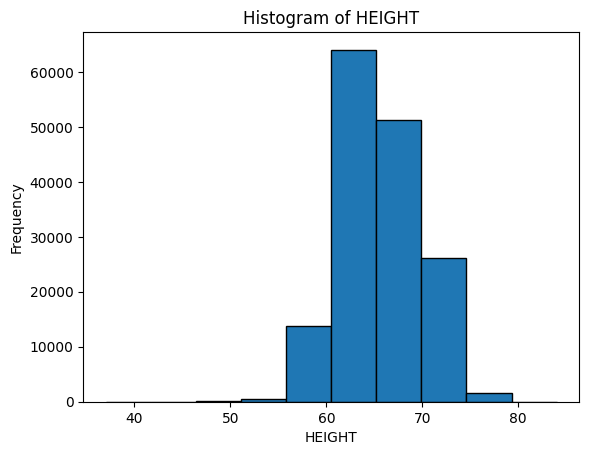

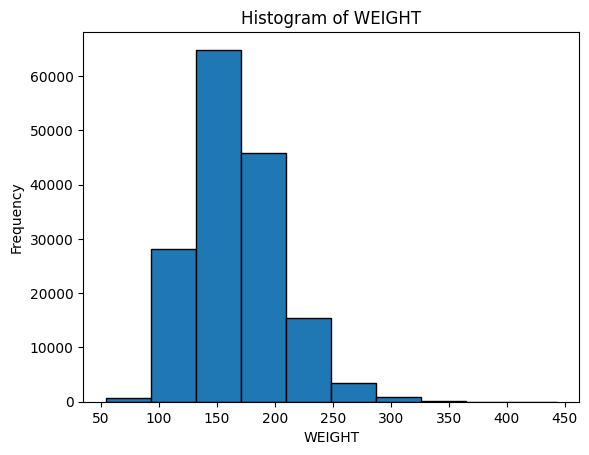

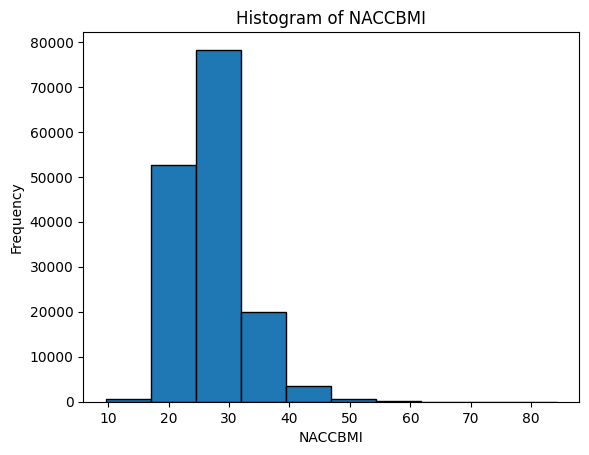

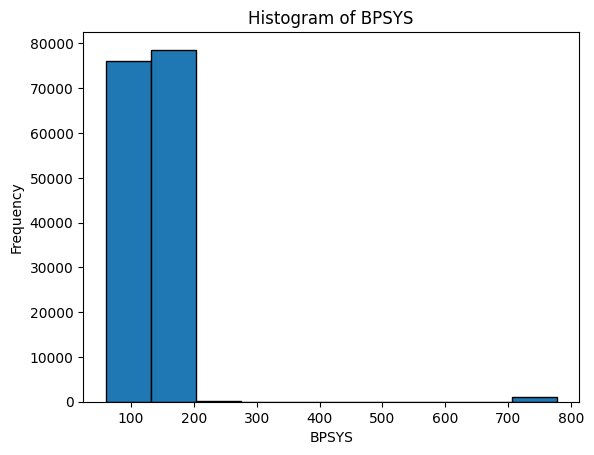

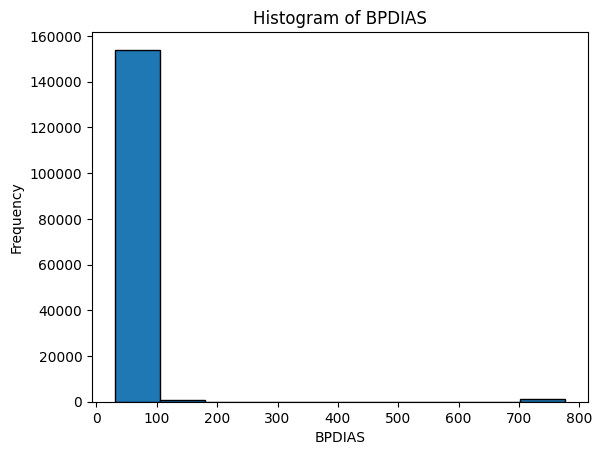

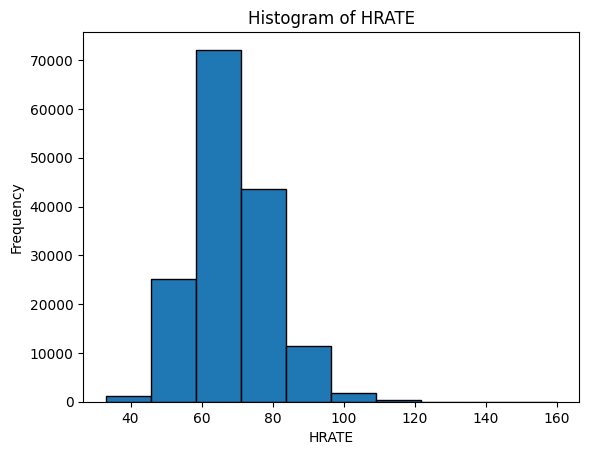

In [ ]:
analyse_data2(b1_data2, filtered_dict, 'b1', 2)

In [ ]:
for i in ['VISION', 'VISCORR', 'HEARING', 'HEARAID']:
    b1_drop_columns.append(i)

In [ ]:
finaldict['b1'].keys()

dict_keys(['HEIGHT', 'WEIGHT', 'NACCBMI', 'BPSYS', 'BPDIAS', 'HRATE', 'VISION', 'VISCORR', 'VISWCORR', 'HEARING', 'HEARAID', 'HEARWAID', 'NACCID', 'VISIT_DATE'])

In [ ]:
# Keys to remove
keys_to_remove = b1_drop_columns

# Drop the keys
for key in keys_to_remove:
    finaldict['b1'].pop(key, None)  # Use pop with default value to avoid KeyError

In [ ]:
ad_data.drop(columns = b1_drop_columns, inplace=True)

In [ ]:
for i in b1_data2.columns[2:]:
    if b1_data2[i].nunique() >= 10:
        print(b1_data2[i].describe())

count    194711.000000
mean         57.682677
std          25.032387
min          -4.000000
25%          61.200000
50%          65.000000
75%          69.000000
max          88.800000
Name: HEIGHT, dtype: float64
count    194711.000000
mean        179.124687
std         174.730889
min          -4.000000
25%         127.000000
50%         158.000000
75%         189.000000
max         888.000000
Name: WEIGHT, dtype: float64
count    195196.000000
mean         83.588301
std         221.819402
min          -4.000000
25%          22.100000
50%          25.800000
75%          30.300000
max         888.800000
Name: NACCBMI, dtype: float64
count    194711.000000
mean        168.884701
std         203.973732
min          -4.000000
25%         115.000000
50%         130.000000
75%         146.000000
max         888.000000
Name: BPSYS, dtype: float64
count    194711.000000
mean        122.190282
std         212.882505
min          -4.000000
25%          64.000000
50%          73.000000
75%       

### b2: HIS and CVD
* All dropped

In [ ]:
b2_drop_columns = null_percentage(filtered_dict, ad_data, 'b2', threshold=0.3)
b2_drop_columns

['ABRUPT',
 'STEPWISE',
 'SOMATIC',
 'EMOT',
 'HXHYPER',
 'HXSTROKE',
 'FOCLSYM',
 'FOCLSIGN',
 'HACHIN',
 'CVDCOG',
 'STROKCOG',
 'CVDIMAG',
 'CVDIMAG1',
 'CVDIMAG2',
 'CVDIMAG3',
 'CVDIMAG4']

In [ ]:
b2_data1, b2_data2 = data_split(filtered_dict, 'b2', ad_data)

In [ ]:
b2_data2.drop(columns = b2_drop_columns, inplace=True)
b2_data2.shape

(195196, 2)

In [ ]:
ad_data.drop(columns = b2_drop_columns, inplace=True)

In [ ]:
for key in b2_drop_columns:
    finaldict['b2'].pop(key, None)

### b3: Unified Parkinson's disease scale

In [ ]:
b3_drop_columns = null_percentage(filtered_dict, ad_data, 'b3', threshold=0.3)
b3_drop_columns

['PDNORMAL',
 'SPEECH',
 'FACEXP',
 'TRESTFAC',
 'TRESTRHD',
 'TRESTLHD',
 'TRESTRFT',
 'TRESTLFT',
 'TRACTRHD',
 'TRACTLHD',
 'RIGDNECK',
 'RIGDUPRT',
 'RIGDUPLF',
 'RIGDLORT',
 'RIGDLOLF',
 'TAPSRT',
 'TAPSLF',
 'HANDMOVR',
 'HANDMOVL',
 'HANDALTR',
 'HANDALTL',
 'LEGRT',
 'LEGLF',
 'ARISING',
 'POSTURE',
 'GAIT',
 'POSSTAB',
 'BRADYKIN']

In [ ]:
b3_data1, b3_data2 = data_split(filtered_dict, 'b3', ad_data)
display(b3_data1.shape)
display(b3_data2.shape)

(52537, 1)

(195196, 30)

In [ ]:
b3_data2.drop(columns = b3_drop_columns, inplace=True)
b3_data2.shape

(195196, 2)

In [ ]:
ad_data.drop(columns = b3_drop_columns, inplace=True)

In [ ]:
for key in b3_drop_columns:
    finaldict['b3'].pop(key, None)

### b4

In [ ]:
for i in list(filtered_dict['b4'].keys())[:-2]:
    filtered_dict['b4'][i]['null_values'].append(99)

In [ ]:
b4_drop_columns = null_percentage(filtered_dict, ad_data, 'b4', threshold=0.3)
b4_drop_columns

[]

In [ ]:
b4_data1, b4_data2 = data_split(filtered_dict, 'b4', ad_data)
display(b4_data1.shape)
display(b4_data2.shape)

(52537, 1)

(195196, 12)

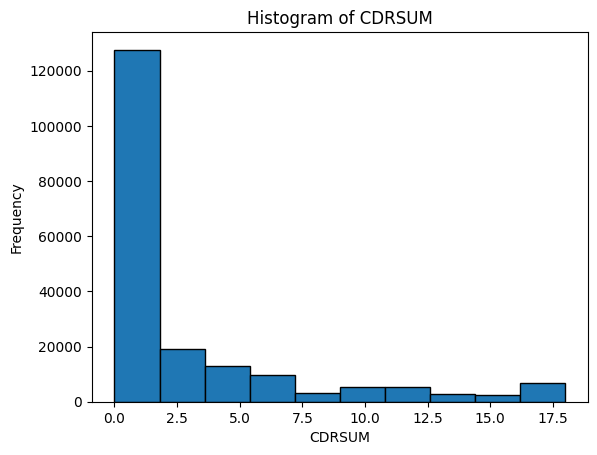

In [ ]:
analyse_data2(b4_data2, filtered_dict, 'b4', 2)

In [ ]:
b4_drop_columns = [i for i in b4_data2.columns[2:] if i != 'CDRSUM' and 'MEMORY' not in i]

In [ ]:
b4_drop_columns

['ORIENT',
 'JUDGMENT',
 'COMMUN',
 'HOMEHOBB',
 'PERSCARE',
 'CDRGLOB',
 'COMPORT',
 'CDRLANG']

In [ ]:
ad_data.drop(columns = b4_drop_columns, inplace=True)

In [ ]:
for key in b4_drop_columns:
    finaldict['b4'].pop(key, None)

### b5: NPIQ

In [ ]:
b5_drop_columns = null_percentage(filtered_dict, ad_data, 'b5', threshold=0.3)
b5_drop_columns

['DELSEV',
 'HALLSEV',
 'AGITSEV',
 'DEPDSEV',
 'ANXSEV',
 'ELATSEV',
 'APASEV',
 'DISNSEV',
 'IRRSEV',
 'MOTSEV',
 'NITESEV',
 'APPSEV']

In [ ]:
for i in b5_drop_columns:
    print(i)
    print(filtered_dict['b5'][i]['ShortDescriptor'], filtered_dict['b5'][i]['null_percentage'])

DELSEV
Delusions severity 0.9420326236193365
HALLSEV
Hallucinations severity 0.9618895879013915
AGITSEV
Agitation or aggression severity 0.8358829074366279
DEPDSEV
Depression or dysphoria severity 0.7791040800016393
ANXSEV
Anxiety severity 0.7932846984569356
ELATSEV
Elation or euphoria severity 0.9742668907149736
APASEV
Apathy or indifference severity 0.8079776224922642
DISNSEV
Disinhibition severity 0.8958892600258203
IRRSEV
Irritability or lability severity 0.7785149285846021
MOTSEV
Motor disturbance severity 0.9089684214840468
NITESEV
Nighttime behaviors severity 0.8195967130473986
APPSEV
Appetite and eating severity 0.859397733560114


In [ ]:
b5_data1, b5_data2 = data_split(filtered_dict, 'b5', ad_data)
display(b5_data1.shape)
display(b5_data2.shape)

(52537, 1)

(195196, 27)

In [ ]:
b5_data2.drop(columns = b5_drop_columns, inplace=True)

In [ ]:
analyse_data(b5_data2, 2)

NPIQINF
 1    99676
 2    43479
 3    40521
-4    11520
Name: count, dtype: int64
DEL
 0    171720
-4     11519
 1     11339
 9       618
Name: count, dtype: int64
HALL
 0    175549
-4     11519
 1      7460
 9       668
Name: count, dtype: int64
AGIT
 0    151323
 1     32076
-4     11519
 9       278
Name: count, dtype: int64
DEPD
 0    139846
 1     43208
-4     11519
 9       623
Name: count, dtype: int64
ANX
 0    142749
 1     40415
-4     11519
 9       513
Name: count, dtype: int64
ELAT
 0    178299
-4     11519
 1      5040
 9       338
Name: count, dtype: int64
APA
 0    145612
 1     37560
-4     11519
 9       505
Name: count, dtype: int64
DISN
 0    162920
 1     20358
-4     11519
 9       399
Name: count, dtype: int64
IRR
 0    140006
 1     43313
-4     11519
 9       358
Name: count, dtype: int64
MOT
 0    165308
 1     17814
-4     11519
 9       555
Name: count, dtype: int64
NITE
 0    145872
 1     35346
-4     11519
 9      2459
Name: count, dtype: int64
APP
 0    

In [ ]:
ad_data.drop(columns = b5_drop_columns, inplace=True)

In [ ]:
for key in b5_drop_columns:
    finaldict['b5'].pop(key, None)

### b6: Geriatric depression scale
* We can just retain NACCGDS which is the total GDS score

In [ ]:
b6_drop_columns = null_percentage(filtered_dict, ad_data, 'b6', threshold=0.3)
b6_drop_columns

[]

In [ ]:
b6_data1, b6_data2 = data_split(filtered_dict, 'b6', ad_data)
display(b6_data1.shape)
display(b6_data2.shape)

(52537, 1)

(195196, 19)

In [ ]:
for i in b6_data2.columns[2:]:
    print(i)
    print(filtered_dict['b6'][i]['ShortDescriptor'])

NOGDS
Is the subject able to complete the GDS, based on the clinician's best judgment?
SATIS
Are you basically satisfied with your life?
DROPACT
Have you dropped many of your activities and interests?
EMPTY
Do you feel that your life is empty?
BORED
Do you often get bored?
SPIRITS
Are you in good spirits most of the time?
AFRAID
Are you afraid that something bad is going to happen to you?
HAPPY
Do you feel happy most of the time?
HELPLESS
Do you often feel helpless?
STAYHOME
Do you prefer to stay at home, rather than going out and doing new things?
MEMPROB
Do you feel you have more problems with memory than most?
WONDRFUL
Do you think it is wonderful to be alive now?
WRTHLESS
Do you feel pretty worthless the way you 
are now?
ENERGY
Do you feel full of energy?
HOPELESS
Do you feel that your situation is hopeless?
BETTER
Do you think that most people are better off than you are?
NACCGDS
Total GDS Score


NOGDS
 0    168924
-4     18461
 1      7811
Name: count, dtype: int64
SATIS
 0    151594
-4     18461
 1     17124
 9      8017
Name: count, dtype: int64
DROPACT
 0    137492
 1     31223
-4     18461
 9      8020
Name: count, dtype: int64
EMPTY
 0    157119
-4     18461
 1     11605
 9      8011
Name: count, dtype: int64
BORED
 0    147445
 1     21326
-4     18461
 9      7964
Name: count, dtype: int64
SPIRITS
 0    158111
-4     18461
 1     10568
 9      8056
Name: count, dtype: int64
AFRAID
 0    152397
-4     18461
 1     16245
 9      8093
Name: count, dtype: int64
HAPPY
 0    151984
-4     18461
 1     16560
 9      8191
Name: count, dtype: int64
HELPLESS
 0    152762
-4     18461
 1     15926
 9      8047
Name: count, dtype: int64
STAYHOME
 0    125649
 1     42594
-4     18461
 9      8492
Name: count, dtype: int64
MEMPROB
 0    122733
 1     45368
-4     18461
 9      8634
Name: count, dtype: int64
WONDRFUL
 0    159836
-4     18461
 1      8636
 9      8263
Name: count, dt

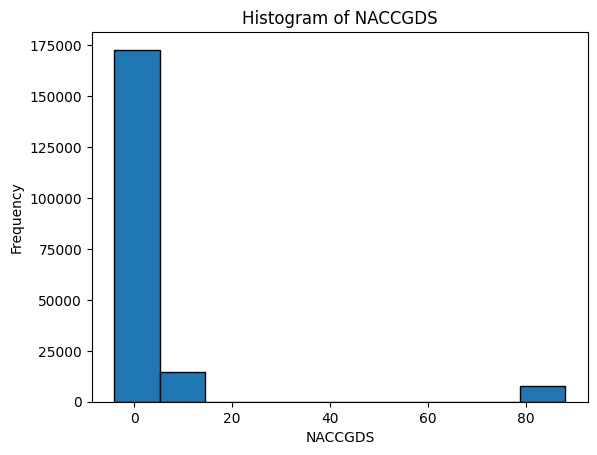

In [ ]:
analyse_data(b6_data2, 2)

In [ ]:
filtered_dict['b6']['NACCGDS']['null_values'].append(88)

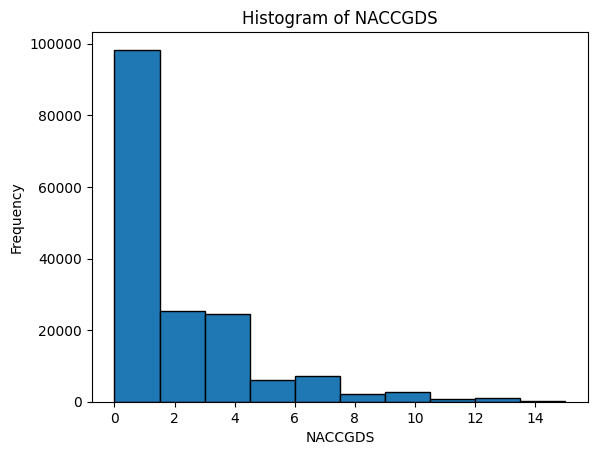

In [ ]:
analyse_data2(b6_data2, filtered_dict, 'b6', 2)

In [ ]:
b6_drop_columns = [i for i in b6_data2.columns[2:] if i not in ['NACCGDS', 'MEMPROB']]

In [ ]:
ad_data.drop(columns = b6_drop_columns, inplace=True)

In [ ]:
for key in b6_drop_columns:
    finaldict['b6'].pop(key, None)

### b7: Functional activity questionnaire

In [ ]:
b7_drop_columns = null_percentage(filtered_dict, ad_data, 'b7', threshold=0.3)
b7_drop_columns

[]

In [ ]:
b7_data1, b7_data2 = data_split(filtered_dict, 'b7', ad_data)
display(b7_data1.shape)
display(b7_data2.shape)

(52537, 1)

(195196, 12)

In [ ]:
for i in b7_data2.columns[2:]:
    print(i)
    print(filtered_dict['b7'][i]['ShortDescriptor'])

BILLS
In the past four weeks, did the subject have any difficulty or need help with: Writing checks, paying bills, or balancing a checkbook
TAXES
In the past four weeks, did the subject have any difficulty or need help with: Assembling tax records, business affairs, or other papers
SHOPPING
In the past four weeks, did the subject have any difficulty or need help with: Shopping alone for clothes, household necessities, or groceries
GAMES
In the past four weeks, did the subject have any difficulty or need help with: Playing a game of skill such as bridge or chess, working on a hobby
STOVE
In the past four weeks, did the subject have any difficulty or need help with: Heating water, making a cup of coffee, turning off the stove
MEALPREP
In the past four weeks, did the subject have any difficulty or need help with: Preparing a balanced meal
EVENTS
In the past four weeks, did the subject have any difficulty or need help with: Keeping track of current events
PAYATTN
In the past four weeks, di

In [ ]:
analyse_data(b7_data2, 2)

BILLS
 0    113667
 3     37203
 8     13024
 1     11607
 2     11077
-4      7791
 9       827
Name: count, dtype: int64
TAXES
 0    108439
 3     39656
 8     17451
 2     10799
 1      9990
-4      7791
 9      1070
Name: count, dtype: int64
SHOPPING
 0    126887
 3     27600
 2     14897
 1     13990
-4      7791
 8      3544
 9       487
Name: count, dtype: int64
GAMES
 0    125647
 3     19163
 1     16928
 8     12719
 2     11374
-4      7791
 9      1574
Name: count, dtype: int64
STOVE
 0    143973
 3     19780
 1     12583
-4      7791
 2      7647
 8      2859
 9       563
Name: count, dtype: int64
MEALPREP
 0    125049
 3     27015
 8     13538
 1     10973
 2     10108
-4      7791
 9       722
Name: count, dtype: int64
EVENTS
 0    131046
 3     20492
 1     19375
 2     14451
-4      7791
 8      1516
 9       525
Name: count, dtype: int64
PAYATTN
 0    133249
 1     24157
 2     14274
 3     14224
-4      7791
 8       817
 9       684
Name: count, dtype: int64
REMDATE

### b8: Physical neurological findings
* Drop

In [ ]:
b8_drop_columns = null_percentage(filtered_dict, ad_data, 'b8', threshold=0.3)
b8_drop_columns

['NORMEXAM',
 'FOCLDEF',
 'GAITDIS',
 'EYEMOVE',
 'PARKSIGN',
 'RESTTRL',
 'RESTTRR',
 'SLOWINGL',
 'SLOWINGR',
 'RIGIDL',
 'RIGIDR',
 'BRADY',
 'PARKGAIT',
 'POSTINST',
 'CVDSIGNS',
 'CORTDEF',
 'SIVDFIND',
 'CVDMOTL',
 'CVDMOTR',
 'CORTVISL',
 'CORTVISR',
 'SOMATL',
 'SOMATR',
 'POSTCORT',
 'PSPCBS',
 'EYEPSP',
 'DYSPSP',
 'AXIALPSP',
 'GAITPSP',
 'APRAXSP',
 'APRAXL',
 'APRAXR',
 'CORTSENL',
 'CORTSENR',
 'ATAXL',
 'ATAXR',
 'ALIENLML',
 'ALIENLMR',
 'DYSTONL',
 'DYSTONR',
 'MYOCLLT',
 'MYOCLRT',
 'ALSFIND',
 'GAITNPH',
 'OTHNEUR']

In [ ]:
b8_data1, b8_data2 = data_split(filtered_dict, 'b8', ad_data)
display(b8_data1.shape)
display(b8_data2.shape)

(52537, 1)

(195196, 48)

In [ ]:
b8_data2.drop(columns = b8_drop_columns, inplace=True)
b8_data2.shape

(195196, 3)

In [ ]:
b8_data2.columns

Index(['NACCID', 'VISIT_DATE', 'NACCNREX'], dtype='object')

In [ ]:
filtered_dict['b8']['NACCNREX']

{'AllowableCodes': ' 0 = Abnormal findings\t  \n1 = No abnormal findings or findings normal for age\n9 = Unknown\n-4 = Not available: UDS form submitted did not collect data in this way, or a skip pattern precludes response to this question',
 'ShortDescriptor': 'Were all findings unremarkable?',
 'DataType': 'Numeric longitudinal',
 'null_values': [9.0, -4.0],
 'null_percentage': 0.13324555831062113,
 'drop_column': 'No'}

In [ ]:
b8_drop_columns.append('NACCNREX')

In [ ]:
ad_data.drop(columns = b8_drop_columns, inplace=True)

In [ ]:
for key in b8_drop_columns:
    finaldict['b8'].pop(key, None)

### b9: Clinician judgement of symptoms

In [ ]:
b9_drop_columns = null_percentage(filtered_dict, ad_data, 'b9', threshold=0.3)
b9_drop_columns

['B9CHG',
 'DECCLIN',
 'DECCLCOG',
 'COGORI',
 'COGFLUC',
 'COGFLAGO',
 'DECCLBE',
 'BEVWELL',
 'BEVHAGO',
 'BEREM',
 'BEREMAGO',
 'BEANX',
 'BEOTHR',
 'BEAGE',
 'DECCLMOT',
 'MOMOPARK',
 'PARKAGE',
 'MOMOALS',
 'ALSAGE',
 'MOAGE',
 'COURSE',
 'FRSTCHG',
 'LBDEVAL',
 'FTLDEVAL']

In [ ]:
b9_data1, b9_data2 = data_split(filtered_dict, 'b9', ad_data)
display(b9_data1.shape)
display(b9_data2.shape)

(99522, 10)

(195196, 45)

In [ ]:
b9_data1.drop(columns = [i for i in b9_data1.columns if i in b9_drop_columns], inplace=True)
b9_data1.shape

(99522, 3)

In [ ]:
b9_data1[['NACCID', 'NACCCOGF']].drop_duplicates().shape

(64779, 2)

In [ ]:
b9_data1[b9_data1['NACCID']=='NACC120323']

,NACCID,NACCCOGF,NACCBEHF
70,NACC120323,1,9
71,NACC120323,1,2
72,NACC120323,1,2


In [ ]:
analyse_data(b9_data1, 1)

NACCCOGF
1     46037
0     36354
3      6037
4      5058
6      2014
99     1859
5      1298
8       376
2       361
7       128
Name: count, dtype: int64
NACCBEHF
0     53486
2     13316
1      9729
5      7176
9      4066
3      1998
4      1938
8      1715
7      1701
6      1647
10     1545
99     1205
Name: count, dtype: int64


In [ ]:
for i in b9_data1.columns[1:]:
    print(i)
    print(filtered_dict['b9'][i]['ShortDescriptor'])

NACCCOGF
Indicate the predominant symptom that was first recognized as a decline in the subject's cognition
NACCBEHF
Indicate the predominant symptom that was first recognized as a decline in the subject's behavior


DECSUB
1    91040
0    90904
9     7526
8     5726
Name: count, dtype: int64
DECIN
1    90987
0    87967
9     9940
8     6302
Name: count, dtype: int64
COGMEM
0    103281
1     91770
9       145
Name: count, dtype: int64
COGJUDG
0    122904
1     71956
9       336
Name: count, dtype: int64
COGLANG
0    144722
1     50003
9       471
Name: count, dtype: int64
COGVIS
0    156705
1     36629
9      1862
Name: count, dtype: int64
COGATTN
0    150022
1     43600
9      1574
Name: count, dtype: int64
COGOTHR
0    191833
1      2190
9      1173
Name: count, dtype: int64
COGMODE
0     97536
1     93301
99     1738
2      1097
3      1052
4       472
Name: count, dtype: int64


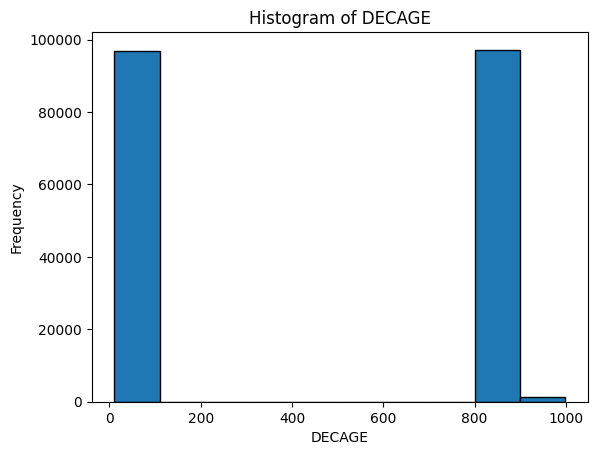

BEAPATHY
0    159637
1     35098
9       461
Name: count, dtype: int64
BEDEP
0    160474
1     33981
9       741
Name: count, dtype: int64
BEVHALL
0    187725
1      6497
9       974
Name: count, dtype: int64
BEAHALL
0    191371
1      2530
9      1295
Name: count, dtype: int64
BEDEL
0    185219
1      8936
9      1041
Name: count, dtype: int64
BEDISIN
0    180316
1     14432
9       448
Name: count, dtype: int64
BEIRRIT
0    165185
1     29568
9       443
Name: count, dtype: int64
BEAGIT
0    178723
1     16099
9       374
Name: count, dtype: int64
BEPERCH
0    184002
1     10520
9       674
Name: count, dtype: int64
BEMODE
0     125165
1      63317
99      2620
2       2204
4       1007
3        883
Name: count, dtype: int64
MOGAIT
0    170346
1     23826
9      1024
Name: count, dtype: int64
MOFALLS
0    181762
1     12476
9       958
Name: count, dtype: int64
MOTREM
0    178573
1     15668
9       955
Name: count, dtype: int64
MOSLOW
0    169302
1     24990
9       904
Name: count,

In [ ]:
b9_data2.drop(columns = [i for i in b9_data2.columns if i in b9_drop_columns], inplace=True)
analyse_data(b9_data2, 2)

In [ ]:
for i in b9_data2.columns[2:]:
    print(i)
    print(filtered_dict['b9'][i]['ShortDescriptor'])

B9CHG
Indicate changes in information reported at previous visit
DECSUB
Does the subject report a decline in memory (relative to previously attained abilities)?
DECIN
Does the co-participant report a decline in subject's memory (relative to previously attained abilities)?
DECCLIN
Clinician believes there is a meaningful decline in memory, non-memory cognitive abilities, behavior, ability to manage his/her affairs, or there are motor/movement changes.
DECCLCOG
Based on the clinician's judgment, is the subject currently experiencing meaningful impairment in cognition?
COGMEM
Indicate whether the subject currently is meaningfully impaired, relative to previously attained abilities, in memory
COGORI
Indicate whether the subject currently is meaningfully impaired, relative to previously attained abilities, in orientation
COGJUDG
Indicate whether the subject currently is meaningfully impaired, relative to previously attained abilities, in executive function - judgment, planning, or problem-s

In [ ]:
ad_data.drop(columns = b9_drop_columns, inplace=True)

In [ ]:
for key in b9_drop_columns:
    finaldict['b9'].pop(key, None)

In [ ]:
finaldict['b9']['NACCCOGF']['DataType'] = 'Numeric longitudinal'
finaldict['b9']['NACCBEHF']['DataType'] = 'Numeric longitudinal'

### c1: MMSE
* MMSELAN, MMSELOC, NACCC1

In [ ]:
c1_drop_columns = null_percentage(filtered_dict, ad_data, 'c1', threshold=0.3)
c1_drop_columns

['MMSECOMP',
 'MMSELAN',
 'MMSELOC',
 'MMSEVIS',
 'MMSEHEAR',
 'MMSEORDA',
 'MMSEORLO',
 'PENTAGON',
 'NACCMMSE',
 'LOGIMO',
 'LOGIDAY',
 'LOGIYR',
 'LOGIPREV',
 'LOGIMEM',
 'MEMUNITS',
 'MEMTIME',
 'DIGIF',
 'DIGIFLEN',
 'DIGIB',
 'DIGIBLEN',
 'WAIS',
 'BOSTON',
 'NACCC1']

In [ ]:
c1_drop_columns.remove('NACCMMSE')
c1_drop_columns.remove('BOSTON')

In [ ]:
ad_data.drop(columns = c1_drop_columns, inplace=True)

In [ ]:
for i in [88, 95, 96, 97, 98]:
    filtered_dict['c1']['NACCMMSE']['null_values'].append(i)

In [ ]:
for i in [95, 96, 97, 98]:
    filtered_dict['c1']['BOSTON']['null_values'].append(i)

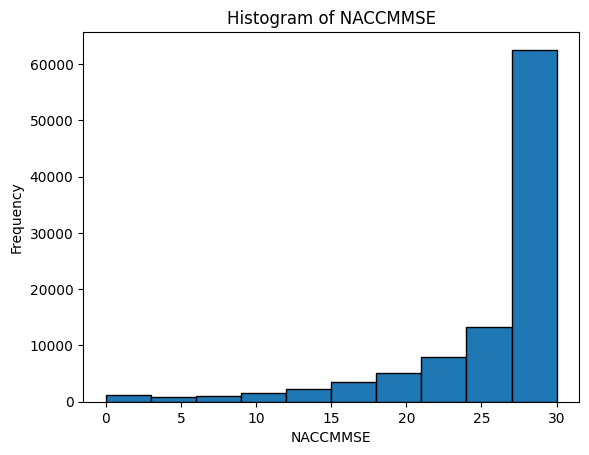

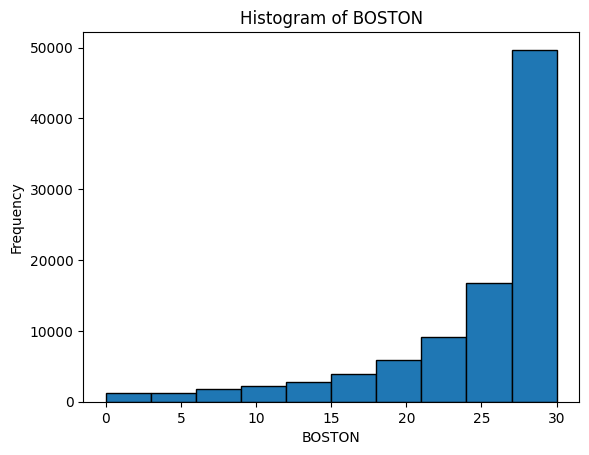

In [ ]:
c1_data1 = ad_data[['NACCID', 'VISIT_DATE', 'NACCMMSE', 'BOSTON']]
analyse_data2(c1_data1, filtered_dict, 'c1', 2)

In [ ]:
print(finaldict['c1']['NACCMMSE']['null_values'])

[-4.0]


In [ ]:
c1_data1[['NACCMMSE', 'BOSTON']].describe()

,NACCMMSE,BOSTON
count,195196.000000,195196.000000
mean,12.879239,14.065298
std,19.061332,22.800886
min,-4.000000,-4.000000
25%,-4.000000,-4.000000
50%,13.000000,10.000000
75%,28.000000,28.000000
max,98.000000,98.000000


In [ ]:
for key in c1_drop_columns:
    finaldict['c1'].pop(key, None)

### c2
* drop

In [ ]:
c2_drop_columns = null_percentage(filtered_dict, ad_data, 'c2', threshold=0.3)
c2_drop_columns

['MOCALOC',
 'MOCAVIS',
 'MOCATOTS',
 'NACCMOCA',
 'MOCATRAI',
 'MOCACUBE',
 'MOCACLOC',
 'MOCACLON',
 'MOCACLOH',
 'MOCANAMI',
 'MOCAREGI',
 'MINTTOTS',
 'MINTTOTW',
 'MINTSCNG',
 'MINTSCNC',
 'MINTPCNG',
 'MINTPCNC',
 'NACCC2']

In [ ]:
c2_data1, c2_data2 = data_split(filtered_dict, 'c2', ad_data)
display(c2_data1.shape)
display(c2_data2.shape)

(52537, 1)

(195196, 20)

In [ ]:
c2_data2.drop(columns = c2_drop_columns, inplace=True)
c2_data2.shape

(195196, 2)

In [ ]:

ad_data.drop(columns = c2_drop_columns, inplace=True)

In [ ]:
for key in c2_drop_columns:
    finaldict['c2'].pop(key, None)

### c1c2: Neurophsychological battery scores

* drop

In [ ]:
c1c2_drop_columns = null_percentage(filtered_dict, ad_data, 'c1c2', threshold=0.3)
c1c2_drop_columns

['UDSBENTC', 'UDSBENTD', 'UDSBENRS']

In [ ]:
c1c2_data1, c1c2_data2 = data_split(filtered_dict, 'c1c2', ad_data)
display(c1c2_data1.shape)
display(c1c2_data2.shape)

(52537, 1)

(195196, 12)

In [ ]:
for i in c1c2_data2.columns[2:]:
    print(i)
    print(filtered_dict['c1c2'][i]['ShortDescriptor'])
    print(filtered_dict['c1c2'][i]['AllowableCodes'])

NPSYCLOC
Where was the remainder of the 
		battery administered?
 1 = In ADC/clinic	 
2 = In home
3 = In person - other 
-4 = Not available: UDS form submitted did not collect data in this way, or a skip pattern precludes response to this question
UDSBENTC
Total Score for copy of Benson figure
 0 - 17	 
95 = Physical problem
96 = Cognitive/behavior problem
97 = Other problem
98 = Verbal refusal
-4 = Not available: UDS form submitted did not collect data in this way, or a skip pattern precludes response to this question
UDSBENTD
Total score for 10- to 15-minute delayed 
drawing of Benson figure
 0 - 17	 
95 = Physical problem
96 = Cognitive/behavior problem
97 = Other problem
98 = Verbal refusal
-4 = Not available: UDS form submitted did not collect data in this way, or a skip pattern precludes response to this question
UDSBENRS
Benson Complex Figure Recall - Recognized original stimulus among 
four options
 0 = No
1 = Yes
-4 = Not available: UDS form submitted did not collect data in t

In [ ]:
c1c2_drop_columns = list(c1c2_data2.columns[2:])

In [ ]:
ad_data.drop(columns = c1c2_drop_columns, inplace=True)

In [ ]:
for key in c1c2_drop_columns:
    finaldict['c1c2'].pop(key, None)

### c1c2c2t: Neurophsychological battery scores
* Retain COGSTAT remove others

In [ ]:
c1c2c2t_drop_columns = null_percentage(filtered_dict, ad_data, 'c1c2c2t', threshold=0.3)
c1c2c2t_drop_columns

['UDSVERFC',
 'UDSVERFN',
 'UDSVERNF',
 'UDSVERLC',
 'UDSVERLR',
 'UDSVERLN',
 'UDSVERTN',
 'UDSVERTE',
 'UDSVERTI']

In [ ]:
c1c2c2t_data1, c1c2c2t_data2 = data_split(filtered_dict, 'c1c2c2t', ad_data)
display(c1c2c2t_data1.shape)
display(c1c2c2t_data2.shape)

(52537, 1)

(195196, 15)

NPSYLAN
 1    171661
-4     16412
 2      6134
 3       989
Name: count, dtype: int64


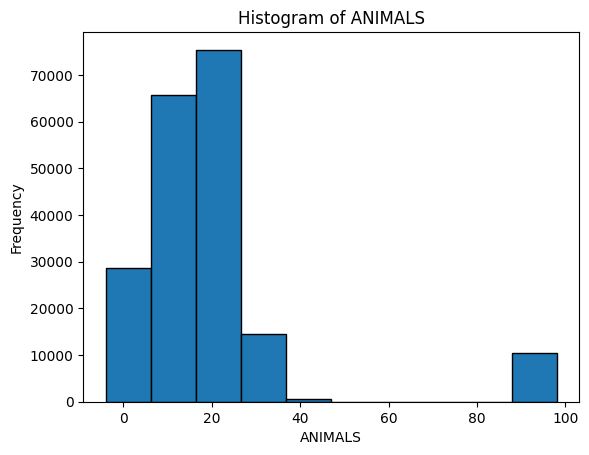

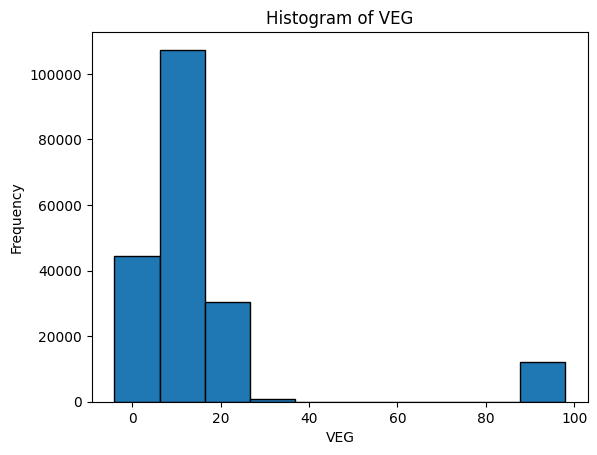

COGSTAT
 2    54028
 4    45236
 3    39132
 0    31792
-4    16412
 1     8596
Name: count, dtype: int64


In [ ]:
c1c2c2t_data2.drop(columns = c1c2c2t_drop_columns, inplace=True)

analyse_data(c1c2c2t_data2, 2)

In [ ]:
for i in c1c2c2t_data2.columns[2:]:
    print(i)
    print(filtered_dict['c1c2c2t'][i]['ShortDescriptor'])
    if i != 'COGSTAT':
        c1c2c2t_drop_columns.append(i)

NPSYLAN
Remainder of battery - Language of 
test administration
ANIMALS
Animals - Total number of animals named 
in 60 seconds
VEG
Vegetables - Total number of vegetables 
named in 60 seconds
COGSTAT
Per the clinician, based on the UDS 
neuropsychological examination, the 
subject's cognitive status is deemed:


In [ ]:
ad_data.drop(columns = c1c2c2t_drop_columns, inplace=True)

In [ ]:
for key in c1c2c2t_drop_columns:
    finaldict['c1c2c2t'].pop(key, None)

### c2c2t
* drop

In [ ]:
c2c2t_drop_columns = null_percentage(filtered_dict, ad_data, 'c2c2t', threshold=0.3)
c2c2t_drop_columns

['MOCACOMP',
 'MOCAREAS',
 'MOCALAN',
 'MOCAHEAR',
 'MOCADIGI',
 'MOCALETT',
 'MOCASER7',
 'MOCAREPE',
 'MOCAFLUE',
 'MOCAABST',
 'MOCARECN',
 'MOCARECC',
 'MOCARECR',
 'MOCAORDT',
 'MOCAORMO',
 'MOCAORYR',
 'MOCAORDY',
 'MOCAORPL',
 'MOCAORCT',
 'CRAFTVRS',
 'CRAFTURS',
 'DIGFORCT',
 'DIGFORSL',
 'DIGBACCT',
 'DIGBACLS',
 'CRAFTDVR',
 'CRAFTDRE',
 'CRAFTDTI',
 'CRAFTCUE']

In [ ]:
c2c2t_data1, c2c2t_data2 = data_split(filtered_dict, 'c2c2t', ad_data)
display(c2c2t_data1.shape)
display(c2c2t_data2.shape)

(52537, 1)

(195196, 31)

In [ ]:
c2c2t_data2.drop(columns = c2c2t_drop_columns, inplace=True)
c2c2t_data2.shape

(195196, 2)

In [ ]:
ad_data.drop(columns = c2c2t_drop_columns, inplace=True)

In [ ]:
ad_data.shape

(195196, 324)

In [ ]:
for key in c2c2t_drop_columns:
    finaldict['c2c2t'].pop(key, None)

## c2t

In [ ]:
c2t_drop_columns = null_percentage(filtered_dict, ad_data, 'c2t', threshold=0.3)
c2t_drop_columns

['MOCBTOTS',
 'NACCMOCB',
 'REY1REC',
 'REY1INT',
 'REY2REC',
 'REY2INT',
 'REY3REC',
 'REY3INT',
 'REY4REC',
 'REY4INT',
 'REY5REC',
 'REY5INT',
 'REY6REC',
 'REY6INT',
 'OTRAILA',
 'OTRLARR',
 'OTRLALI',
 'OTRAILB',
 'OTRLBRR',
 'OTRLBLI',
 'REYDREC',
 'REYDINT',
 'REYTCOR',
 'REYFPOS',
 'VNTTOTW',
 'VNTPCNC',
 'RESPVAL',
 'RESPHEAR',
 'RESPDIST',
 'RESPINTR',
 'RESPDISN',
 'RESPFATG',
 'RESPEMOT',
 'RESPASST',
 'RESPOTH']

In [ ]:
c2t_data1, c2t_data2 = data_split(filtered_dict, 'c2t', ad_data)
display(c2t_data1.shape)
display(c2t_data2.shape)

(52537, 1)

(195196, 39)

In [ ]:
c2t_data2.drop(columns = [i for i in c2t_data2.columns if i in c2t_drop_columns], inplace=True)
c2t_data2.shape

(195196, 4)

In [ ]:
c2t_data2.columns

Index(['NACCID', 'VISIT_DATE', 'MODCOMM', 'RESPOTHX'], dtype='object')

In [ ]:
c2t_drop_columns.append('MODCOMM')
c2t_drop_columns.append('RESPOTHX')

In [ ]:
ad_data.drop(columns = c2t_drop_columns, inplace=True)

In [ ]:
for key in c2t_drop_columns:
    finaldict['c2t'].pop(key, None)

### d1: Diagnosis
* check

In [ ]:
d1_drop_columns = null_percentage(filtered_dict, ad_data, 'd1', threshold=0.3)
d1_drop_columns

['WHODIDDX',
 'DXMETHOD',
 'AMNDEM',
 'PCA',
 'NACCPPAG',
 'NACCPPME',
 'NAMNDEM',
 'AMYLPET',
 'AMYLCSF',
 'FDGAD',
 'HIPPATR',
 'TAUPETAD',
 'CSFTAU',
 'FDGFTLD',
 'TPETFTLD',
 'MRFTLD',
 'DATSCAN',
 'OTHBIOM',
 'IMAGLINF',
 'IMAGLAC',
 'IMAGMACH',
 'IMAGMICH',
 'IMAGMWMH',
 'IMAGEWMH',
 'OTHMUT',
 'PROBAD',
 'PROBADIF',
 'POSSAD',
 'POSSADIF',
 'MSA',
 'MSAIF',
 'FTLDMO',
 'FTLDMOIF',
 'FTLDNOS',
 'FTLDNOIF',
 'FTD',
 'FTDIF',
 'PPAPH',
 'PPAPHIF',
 'FTLDSUBT',
 'CVD',
 'CVDIF',
 'PREVSTK',
 'STROKDEC',
 'STKIMAG',
 'INFNETW',
 'INFWMH',
 'VASC',
 'VASCIF',
 'VASCPS',
 'VASCPSIF',
 'STROKE',
 'STROKIF',
 'ESSTREM',
 'ESSTREIF',
 'BRNINCTE',
 'EPILEP',
 'EPILEPIF',
 'NEOPSTAT',
 'HIV',
 'HIVIF',
 'OTHCOG',
 'OTHCOGIF',
 'DEPTREAT',
 'BIPOLDX',
 'BIPOLDIF',
 'SCHIZOP',
 'SCHIZOIF',
 'ANXIET',
 'ANXIETIF',
 'DELIR',
 'DELIRIF',
 'PTSDDX',
 'PTSDDXIF',
 'ALCABUSE',
 'IMPSUB',
 'IMPSUBIF',
 'DEMUN',
 'DEMUNIF',
 'NACCADMU',
 'NACCFTDM',
 'NACCETPR']

In [ ]:
len(d1_drop_columns)

82

In [ ]:
d1_data1, d1_data2 = data_split(filtered_dict, 'd1', ad_data)
display(d1_data1.shape)
display(d1_data2.shape)

(52537, 6)

(195196, 131)

In [ ]:
d1_data1.drop(columns = [i for i in d1_data1.columns if i in d1_drop_columns], inplace=True)
d1_data1.shape

(52537, 4)

In [ ]:
d1_data2.drop(columns = [i for i in d1_data2.columns if i in d1_drop_columns], inplace=True)
d1_data2.shape

(195196, 51)

In [ ]:
for i in d1_data1.columns[1:]:
    print(i)
    print(filtered_dict['d1'][i]['ShortDescriptor'])

NACCNORM
Normal cognition at all visits to date
NACCIDEM
Incident dementia during UDS follow-up
NACCMCII
Incident MCI during UDS follow-up


In [ ]:
d1_data2['NACCALZD'].value_counts()

,count
NACCALZD,
8,94933
1,67754
0,32509


In [ ]:
for i in d1_data2.columns[2:]:
    print(i)
    print(filtered_dict['d1'][i]['ShortDescriptor'])

NORMCOG
Normal cognition and behavior
DEMENTED
Met criteria for dementia
NACCUDSD
Cognitive status at UDS visit
NACCPPA
Primary progressive aphasia (PPA) with cognitive impairment
NACCBVFT
Dementia syndrome - behavioral variant FTD syndrome (bvFTD)
NACCLBDS
Dementia syndrome - Lewy body 
dementia syndrome
NACCTMCI
Mild cognitive impairment (MCI) type
NACCMCIL
MCI domain affected - language
NACCMCIA
MCI domain affected - attention
NACCMCIE
MCI domain affected - executive function
NACCMCIV
MCI domain affected - visuospatial
IMPNOMCI
Cognitively impaired, not MCI
NACCALZD
Presumptive etiologic diagnosis of the cognitive disorder - Alzheimer's disease
NACCALZP
Primary, contributing, or non-contributing cause of observed cognitive impairment - Alzheimer's disease (AD)
NACCLBDE
Presumptive etiologic diagnosis - Lewy body disease
NACCLBDP
Primary, contributing, or non-contributing cause of cognitive impairment - Lewy body disease (LBD)
PARK
Parkinson's disease present
PSP
Presumptive etiologi

In [ ]:
ad_data.drop(columns = d1_drop_columns, inplace=True)

In [ ]:
for key in d1_drop_columns:
    finaldict['d1'].pop(key, None)

### d2: Medical conditions
* drop all

In [ ]:
d2_drop_columns = null_percentage(filtered_dict, ad_data, 'd2', threshold=0.3)
d2_drop_columns

['CANCER',
 'DIABET',
 'MYOINF',
 'CONGHRT',
 'AFIBRILL',
 'HYPERT',
 'ANGINA',
 'HYPCHOL',
 'VB12DEF',
 'THYDIS',
 'ARTH',
 'ARTYPE',
 'ARTUPEX',
 'ARTLOEX',
 'ARTSPIN',
 'ARTUNKN',
 'URINEINC',
 'BOWLINC',
 'SLEEPAP',
 'REMDIS',
 'HYPOSOM',
 'SLEEPOTH',
 'ANGIOCP',
 'ANGIOPCI',
 'PACEMAKE',
 'HVALVE',
 'ANTIENC',
 'OTHCOND']

In [ ]:
d2_data1, d2_data2 = data_split(filtered_dict, 'd2', ad_data)
display(d2_data1.shape)
display(d2_data2.shape)

(52537, 1)

(195196, 30)

In [ ]:
d2_data2.drop(columns = d2_drop_columns, inplace=True)
d2_data2.shape

(195196, 2)

In [ ]:
ad_data.drop(columns = d2_drop_columns, inplace=True)

In [ ]:
ad_data.shape

(195196, 177)

In [ ]:
for key in d2_drop_columns:
    finaldict['d2'].pop(key, None)

## Table one

In [ ]:
form_list = list(finaldict.keys())

In [ ]:
for i in form_list:
    if len(finaldict[i].keys())<=2:
        finaldict.pop(i, None)

In [ ]:
cross_sectional_list = []
longitudinal_list = []
for i in finaldict.keys():
    for j in list(finaldict[i].keys())[:-2]:
        if 'cross-sectional' in finaldict[i][j]['DataType'].lower():
            cross_sectional_list.append(j)
        else:
            longitudinal_list.append(j)

In [ ]:
cross_sectional_list.append('NACCID')
longitudinal_list.append('NACCID')
longitudinal_list.append('VISIT_DATE')

In [ ]:
object_columns = ad_data.select_dtypes(include=['object']).columns
print(object_columns)

Index(['NACCID'], dtype='object')


In [ ]:
def continuous_vars(data, var_list):
    continuous = []
    categorical = []
    for i in var_list:
        if data[i].nunique() >= 10:
            continuous.append(i)
        else:
            categorical.append(i)
    return continuous, categorical

In [ ]:
cs_continuous, cs_categorical = continuous_vars(ad_data, cross_sectional_list[:-1])
long_continuous, long_categorical = continuous_vars(ad_data, longitudinal_list[:-2])

In [ ]:
!pip install tableone
from tableone import TableOne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.8 MB/s eta 0:00:00


In [ ]:
ad_data[ad_data['NACCALZD']==1]['NACCID'].nunique()

24863

In [ ]:
final_data = ad_data.copy()

In [ ]:
for i in finaldict.keys():
    for j in list(finaldict[i].keys())[:-2]:
        if finaldict[i][j]['null_values']:
            final_data[j] = final_data[j].replace(finaldict[i][j]['null_values'], np.nan)

### Patient-Visit Date level

In [ ]:
ad_visit_lvl_data = final_data[longitudinal_list]

In [ ]:
ad_visit_lvl_data[['HEIGHT', 'WEIGHT', 'BPSYS', 'BPDIAS', 'HRATE', 'DECAGE']].isna().sum()

,0
HEIGHT,37841
WEIGHT,35994
BPSYS,39317
BPDIAS,39329
HRATE,39648
DECAGE,1220


In [ ]:
ad_pat_list = ad_visit_lvl_data[ad_visit_lvl_data['NACCALZD']==1]['NACCID'].unique()

In [ ]:
len(ad_pat_list)

24863

In [ ]:
ad_pats = ad_visit_lvl_data[ad_visit_lvl_data['NACCID'].isin(ad_pat_list)]

In [ ]:
ad_pats = ad_pats[['NACCID', 'VISIT_DATE', 'NACCALZD']]
# Sort by ID and date to ensure proper ordering
ad_pats = ad_pats.sort_values(by=["NACCID", "VISIT_DATE"])

# Shift the status column to check the next visit's status
ad_pats["next_NACCALZD"] = ad_pats.groupby("NACCID")["NACCALZD"].shift(-1)

In [ ]:
status_changes = ad_pats[(ad_pats["NACCALZD"] == 1) & (ad_pats["next_NACCALZD"].isin([0, 8]))]

In [ ]:
status_changes.shape

(3959, 4)

In [ ]:
status_changes['NACCID'].nunique()

3508

In [ ]:
status_changes.head(10)

,NACCID,VISIT_DATE,NACCALZD,next_NACCALZD
33209,NACC000011,2008-06-03,1,0.0
100767,NACC000162,2010-03-23,1,0.0
189567,NACC001169,2011-04-22,1,0.0
88929,NACC002288,2019-07-08,1,0.0
54841,NACC002337,2007-09-04,1,0.0
1085,NACC002373,2017-02-09,1,0.0
24165,NACC002424,2019-02-06,1,8.0
24168,NACC002424,2022-05-26,1,8.0
118613,NACC002616,2015-02-23,1,8.0
164034,NACC002782,2014-06-23,1,0.0


In [ ]:
ad_pats[ad_pats['NACCID']=='NACC003867']

,NACCID,VISIT_DATE,NACCALZD,next_NACCALZD
118629,NACC003867,2006-02-24,8,8.0
118630,NACC003867,2007-04-02,8,8.0
118631,NACC003867,2008-11-07,8,1.0
118632,NACC003867,2010-04-15,1,8.0
118633,NACC003867,2011-05-05,8,8.0
118634,NACC003867,2012-04-09,8,8.0
118635,NACC003867,2013-02-15,8,NaN


In [ ]:
ad_pats[ad_pats['NACCID']=='NACC002424']

,NACCID,VISIT_DATE,NACCALZD,next_NACCALZD
24163,NACC002424,2017-01-12,8,1.0
24164,NACC002424,2018-02-06,1,1.0
24165,NACC002424,2019-02-06,1,8.0
24166,NACC002424,2020-05-05,8,8.0
24167,NACC002424,2021-06-23,8,1.0
24168,NACC002424,2022-05-26,1,8.0
24169,NACC002424,2024-01-09,8,NaN


In [ ]:
# Filter NACCIDs with counts greater than 1
filtered_naccids = status_changes['NACCID'].value_counts()
filtered_naccids = filtered_naccids[filtered_naccids > 1].index

In [ ]:
len(filtered_naccids)

404

In [ ]:
status_changes[status_changes['NACCID'].isin(filtered_naccids)].head(10)

,NACCID,VISIT_DATE,NACCALZD,next_NACCALZD
24165,NACC002424,2019-02-06,1,8.0
24168,NACC002424,2022-05-26,1,8.0
118655,NACC005258,2008-11-12,1,0.0
118657,NACC005258,2011-07-20,1,0.0
100796,NACC006312,2009-07-16,1,0.0
100800,NACC006312,2013-12-03,1,0.0
126012,NACC006420,2015-09-01,1,0.0
126015,NACC006420,2018-07-19,1,0.0
175013,NACC006983,2011-10-31,1,0.0
175018,NACC006983,2017-11-07,1,0.0


In [ ]:
ad_pats['has_alzheimers'] = ad_pats.groupby('NACCID')['NACCALZD'].transform(lambda x: (x == 1).cummax())
# ad_pats.loc[ad_pats['has_alzheimers'], 'NACCALZD'] = 1
# ad_pats.drop(columns=['has_alzheimers'], inplace=True)

In [ ]:
ad_pats[ad_pats['NACCID']=='NACC003867']

,NACCID,VISIT_DATE,NACCALZD,next_NACCALZD,has_alzheimers
118629,NACC003867,2006-02-24,8,8.0,False
118630,NACC003867,2007-04-02,8,8.0,False
118631,NACC003867,2008-11-07,8,1.0,False
118632,NACC003867,2010-04-15,1,8.0,True
118633,NACC003867,2011-05-05,8,8.0,True
118634,NACC003867,2012-04-09,8,8.0,True
118635,NACC003867,2013-02-15,8,NaN,True


In [ ]:
ad_pats.loc[ad_pats['has_alzheimers'], 'NACCALZD'] = 1

In [ ]:
ad_pats[ad_pats['NACCID']=='NACC003867']

,NACCID,VISIT_DATE,NACCALZD,next_NACCALZD,has_alzheimers
118629,NACC003867,2006-02-24,8,8.0,False
118630,NACC003867,2007-04-02,8,8.0,False
118631,NACC003867,2008-11-07,8,1.0,False
118632,NACC003867,2010-04-15,1,8.0,True
118633,NACC003867,2011-05-05,1,8.0,True
118634,NACC003867,2012-04-09,1,8.0,True
118635,NACC003867,2013-02-15,1,NaN,True


In [ ]:
table_visit_lvl = TableOne(ad_visit_lvl_data, list(ad_visit_lvl_data.columns), long_categorical, long_continuous, groupby='NACCALZD')

In [ ]:
table_visit_lvl

Grouped by NACCALZD                                                             
                                     Missing         Overall              0              1              8
n                                                     195196          32509          67754          94933
NACCLIVS, n (%)     1.0                         49827 (25.5)    6815 (21.0)   11506 (17.0)   31506 (33.2)
                    2.0                        114901 (58.9)   20132 (61.9)   40986 (60.5)   53783 (56.7)
                    3.0                          15487 (7.9)     2593 (8.0)     6690 (9.9)     6204 (6.5)
                    4.0                          10916 (5.6)     2166 (6.7)     5783 (8.5)     2967 (3.1)
                    5.0                           3741 (1.9)      736 (2.3)     2688 (4.0)      317 (0.3)
                    None                           324 (0.2)       67 (0.2)      101 (0.1)      156 (0.2)
INDEPEND, n (%)     1.0                        134206 (68.8)   18273 (56.2)   23525 (34.7)   92408 (97.3)
                    2.0                         31748 (16.3)    7569 (23.3)   22289 (32.9)     1890 (2.0)
                    3.0                          17889 (9.2)    3930 (12.1)   13473 (19.9)      486 (0.5)
                    4.0                          10756 (5.5)     2565 (7.9)    8137 (12.0)       54 (0.1)
                    None                           597 (0.3)      172 (0.5)      330 (0.5)       95 (0.1)
NACCAGE, mean (SD)                         0     74.4 (10.3)    71.9 (10.3)     76.7 (9.8)    73.5 (10.3)
ANYMEDS, n (%)      0.0                           7644 (3.9)     1413 (4.3)     1685 (2.5)     4546 (4.8)
                    1.0                        184813 (94.7)   30753 (94.6)   65326 (96.4)   88734 (93.5)
                    None                          2739 (1.4)      343 (1.1)      743 (1.1)     1653 (1.7)
NACCAMD, mean (SD)                      2739       6.7 (4.2)      6.8 (4.4)      7.0 (4.1)      6.5 (4.2)
NACCAHTN, n (%)     0.0                         86110 (44.1)   14047 (43.2)   29463 (43.5)   42600 (44.9)
                    1.0                        106347 (54.5)   18119 (55.7)   37548 (55.4)   50680 (53.4)
                    None                          2739 (1.4)      343 (1.1)      743 (1.1)     1653 (1.7)
NACCHTNC, n (%)     0.0                        184309 (94.4)   30893 (95.0)   64523 (95.2)   88893 (93.6)
                    1.0                           8148 (4.2)     1273 (3.9)     2488 (3.7)     4387 (4.6)
                    None                          2739 (1.4)      343 (1.1)      743 (1.1)     1653 (1.7)
NACCACEI, n (%)     0.0                        160450 (82.2)   26656 (82.0)   55121 (81.4)   78673 (82.9)
                    1.0                         32007 (16.4)    5510 (16.9)   11890 (17.5)   14607 (15.4)
                    None                          2739 (1.4)      343 (1.1)      743 (1.1)     1653 (1.7)
NACCAAAS, n (%)     0.0                        175223 (89.8)   28582 (87.9)   60435 (89.2)   86206 (90.8)
                    1.0                          17234 (8.8)    3584 (11.0)     6576 (9.7)     7074 (7.5)
                    None                          2739 (1.4)      343 (1.1)      743 (1.1)     1653 (1.7)
NACCBETA, n (%)     0.0                        152785 (78.3)   25131 (77.3)   53040 (78.3)   74614 (78.6)
                    1.0                         39672 (20.3)    7035 (21.6)   13971 (20.6)   18666 (19.7)
                    None                          2739 (1.4)      343 (1.1)      743 (1.1)     1653 (1.7)
NACCCCBS, n (%)     0.0                        161167 (82.6)   26886 (82.7)   55977 (82.6)   78304 (82.5)
                    1.0                         31290 (16.0)    5280 (16.2)   11034 (16.3)   14976 (15.8)
                    None                          2739 (1.4)      343 (1.1)      743 (1.1)     1653 (1.7)
NACCDIUR, n (%)     0.0                        162923 (83.5)   27234 (83.8)   57286 (84.5)   78403 (82.

In [ ]:
finaldict['a1']['NACCLIVS']['ShortDescriptor']

'Living situation'

In [ ]:
final_data.shape

(195196, 177)

In [ ]:
table_visit_lvl.to_csv('table_visit_lvl.csv')

### Patient level

In [ ]:
ad_data.shape, ad_data['NACCID'].nunique()

((195196, 177), 52537)

In [ ]:
ad_data.head()

,NACCID,SEX,EDUC,NACCLIVS,INDEPEND,NACCFAM,NACCMOM,NACCDAD,ANYMEDS,TOBAC30,...,NACCEMD,NACCEPMD,NACCHTNC,NACCLIPL,NACCNSD,NACCPDMD,NACCVASD,NACCBMI,NACCUDSD,VISIT_DATE
0,NACC002909,1,16,4,1,1,0,0,1,0,...,0,0,0,0,1,0,0,32.4,3,2022-12-28
1,NACC002909,1,16,2,1,1,0,0,1,-4,...,0,0,1,1,0,0,0,30.7,3,2024-01-23
2,NACC003487,1,16,2,1,0,0,0,1,0,...,0,0,0,0,0,0,0,23.7,1,2023-11-15
3,NACC004352,2,16,2,2,-4,-4,-4,1,0,...,0,0,0,0,0,0,0,888.8,4,2021-10-05
4,NACC004687,1,12,1,1,9,0,0,1,0,...,0,0,0,0,0,0,0,19.0,1,2022-11-14


In [ ]:
ad_id_lvl_data = ad_data[cross_sectional_list+['VISIT_DATE', 'NACCALZD']]
ad_id_lvl_data1 = ad_id_lvl_data.loc[ad_id_lvl_data.groupby("NACCID")["VISIT_DATE"].idxmin()]

In [ ]:
ad_id_lvl_data1

,SEX,EDUC,NACCAGEB,NACCFAM,NACCMOM,NACCDAD,NACCNORM,NACCIDEM,NACCMCII,NACCID,VISIT_DATE,NACCALZD
33207,2,16,62,9,9,9,0,0,1,NACC000011,2006-04-17,0
189554,2,15,79,1,1,1,0,1,1,NACC000034,2015-07-16,1
36116,1,18,60,1,1,0,0,0,1,NACC000067,2012-05-23,0
100765,2,18,44,0,0,0,1,0,0,NACC000073,2016-05-20,8
54831,1,16,87,1,0,0,0,8,0,NACC000095,2014-05-23,1
...,...,...,...,...,...,...,...,...,...,...,...,...
152584,2,20,79,0,0,0,1,0,0,NACC999854,2006-08-14,8
163999,2,14,70,1,0,1,0,0,0,NACC999872,2005-09-02,0
60775,1,12,62,9,9,9,1,0,0,NACC999922,2012-08-07,8
88908,2,9,70,9,9,9,0,8,0,NACC999954,2006-03-27,1


In [ ]:
ad_id_lvl_data['NACCID'].nunique(), ad_id_lvl_data.shape

(52537, (195196, 12))

In [ ]:
ad_id_lvl_data.drop(columns = ['VISIT_DATE'], inplace=True)

In [ ]:
mytable = TableOne(ad_id_lvl_data1, list(ad_id_lvl_data.columns), cs_categorical, cs_continuous, groupby='NACCALZD')

In [ ]:
mytable

Grouped by NACCALZD                                                          
                                   Missing       Overall              0              1             8
n                                                  52537          12041          19037         21459
SEX, n (%)          1                       22432 (42.7)    6239 (51.8)    8768 (46.1)   7425 (34.6)
                    2                       30105 (57.3)    5802 (48.2)   10269 (53.9)  14034 (65.4)
EDUC, mean (SD)                          0    15.9 (7.9)     15.8 (9.2)     15.4 (8.3)    16.3 (6.6)
NACCAGEB, mean (SD)                      0   71.1 (10.5)    69.8 (10.2)     73.7 (9.6)   69.5 (10.8)
NACCFAM, n (%)      -4                         621 (1.2)      107 (0.9)      159 (0.8)     355 (1.7)
                    0                       18996 (36.2)    4793 (39.8)    6715 (35.3)   7488 (34.9)
                    1                       26969 (51.3)    5553 (46.1)    9922 (52.1)  11494 (53.6)
                    9                        5951 (11.3)    1588 (13.2)    2241 (11.8)    2122 (9.9)
NACCMOM, n (%)      -4                         621 (1.2)      107 (0.9)      159 (0.8)     355 (1.7)
                    0                       33335 (63.5)    8100 (67.3)   12157 (63.9)  13078 (60.9)
                    1                       17096 (32.5)    3443 (28.6)    5921 (31.1)   7732 (36.0)
                    9                         1485 (2.8)      391 (3.2)      800 (4.2)     294 (1.4)
NACCDAD, n (%)      -4                         621 (1.2)      107 (0.9)      159 (0.8)     355 (1.7)
                    0                       41181 (78.4)    9571 (79.5)   14735 (77.4)  16875 (78.6)
                    1                        8501 (16.2)    1767 (14.7)    2991 (15.7)   3743 (17.4)
                    9                         2234 (4.3)      596 (4.9)     1152 (6.1)     486 (2.3)
NACCNORM, n (%)     0                       35608 (67.8)  12041 (100.0)  19037 (100.0)   4530 (21.1)
                    1                       16929 (32.2)                                16929 (78.9)
NACCIDEM, n (%)     0                       30478 (58.0)    6370 (52.9)    3947 (20.7)  20161 (94.0)
                    1                         5009 (9.5)    1781 (14.8)    1930 (10.1)    1298 (6.0)
                    8                       17050 (32.5)    3890 (32.3)   13160 (69.1)              
NACCMCII, n (%)     0                       41956 (79.9)    8311 (69.0)   15941 (83.7)  17704 (82.5)
                    1                        9948 (18.9)    3622 (30.1)    3065 (16.1)   3261 (15.2)
                    8                          633 (1.2)      108 (0.9)       31 (0.2)     494 (2.3)

In [ ]:
finaldict['d1']['NACCNORM']['ShortDescriptor']

'Normal cognition at all visits to date'

In [ ]:
finaldict['d1']['NACCIDEM']['ShortDescriptor']

'Incident dementia during UDS follow-up'

In [ ]:
finaldict['d1']['NACCMCII']['ShortDescriptor']

'Incident MCI during UDS follow-up'

In [ ]:
mytable.to_csv('table_id_lvl.csv')

In [ ]:
data_dict[data_dict['VariableName']=='VNTPCNC']

,VariableName,Form,VariableType,ShortDescriptor,DataType,AllowableCodes
580,VNTPCNC,c2t,Original UDS question,Verbal Naming Test - Total correct with a phon...,Numeric longitudinal,"0-50\n88=Not assessed, optional\n95=Physical p..."


In [ ]:
data_dict[data_dict['VariableName'].isin(final_data.columns)]['Form'].unique()

array(['header', 'a1', 'a3', 'a4', 'a5', 'b1', 'b4', 'b5', 'b6', 'b7',
       'b9', 'c1c2c2t', 'c1', 'd1'], dtype=object)

In [ ]:
data_dict[data_dict['VariableName'].isin(final_data.columns)].to_csv('data_dict_final.csv', index=False)